# AI Personalized Learning Agent
## Full EDA Pipeline (Steps 1-8)

**Dataset**: UCI Student Performance Dataset  
**Source**: https://archive.ics.uci.edu/dataset/320/student-performance  
**Students**: 1,044 (Math + Portuguese combined)  
**Features**: 33 attributes — demographics, social, school, grades  
**Target**: G3 (final grade 0-20)  

---
### Pipeline Overview
| Step | Task | Key Finding |
|------|------|-------------|
| 1 | Load & Audit | 1044 students, 33 features, 0 missing |
| 2 | Missing Analysis | 100% completeness |
| 3 | Distribution EDA | G3 skew = -0.99 |
| 4 | Time-Series EDA | 53 dropouts, 487 improved |
| 5 | Categorical EDA | Urban students score higher |
| 6 | Correlation | G2 r=0.911 strongest predictor |
| 7 | Class Imbalance | 1:3.5 ratio (pass vs at-risk) |
| 8 | Target Engineering | Mastery levels 0-4 for DKT |


## Step 0: Imports & Setup


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.titlesize'] = 14

PLOT_DIR = os.path.join('..', 'reports', 'eda_plots')
os.makedirs(PLOT_DIR, exist_ok=True)
print(f'Plot directory: {os.path.abspath(PLOT_DIR)}')


Plot directory: d:\Day 1\project\reports\eda_plots


## Step 1: Load & Audit
> Load both CSV files, merge into one dataset, check dtypes, memory, and duplicates.


In [2]:
DATA_DIR = os.path.join('..', 'data', 'raw', 'student_performance')
df_mat = pd.read_csv(os.path.join(DATA_DIR, 'student-mat.csv'), sep=';')
df_por = pd.read_csv(os.path.join(DATA_DIR, 'student-por.csv'), sep=';')

print(f'Math:       {df_mat.shape}')
print(f'Portuguese: {df_por.shape}')

df = pd.concat([df_mat, df_por], ignore_index=True)
print(f'Combined:   {df.shape}')


Math:       (395, 33)
Portuguese: (649, 33)
Combined:   (1044, 33)


In [3]:
# Column summary
col_info = pd.DataFrame({
    'dtype': df.dtypes,
    'unique': df.nunique(),
    'nulls': df.isnull().sum(),
    'null_pct': (df.isnull().mean() * 100).round(2)
})
col_info


,dtype,unique,nulls,null_pct
school,object,2,0,0.0
sex,object,2,0,0.0
age,int64,8,0,0.0
address,object,2,0,0.0
famsize,object,2,0,0.0
Pstatus,object,2,0,0.0
Medu,int64,5,0,0.0
Fedu,int64,5,0,0.0
Mjob,object,5,0,0.0
Fjob,object,5,0,0.0


In [4]:
print(f'Memory: {df.memory_usage(deep=True).sum()/1024**2:.2f} MB')
n_dupes = df.duplicated().sum()
print(f'Duplicates: {n_dupes}')
if n_dupes > 0:
    df = df.drop_duplicates().reset_index(drop=True)
df.describe().round(2)


Memory: 1.01 MB
Duplicates: 0


,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
count,1044.00,1044.00,1044.00,1044.00,1044.00,1044.00,1044.00,1044.00,1044.00,1044.00,1044.00,1044.00,1044.00,1044.00,1044.00,1044.00
mean,16.73,2.60,2.39,1.52,1.97,0.26,3.94,3.20,3.16,1.49,2.28,3.54,4.43,11.21,11.25,11.34
std,1.24,1.12,1.10,0.73,0.83,0.66,0.93,1.03,1.15,0.91,1.29,1.42,6.21,2.98,3.29,3.86
min,15.00,0.00,0.00,1.00,1.00,0.00,1.00,1.00,1.00,1.00,1.00,1.00,0.00,0.00,0.00,0.00
25%,16.00,2.00,1.00,1.00,1.00,0.00,4.00,3.00,2.00,1.00,1.00,3.00,0.00,9.00,9.00,10.00
50%,17.00,3.00,2.00,1.00,2.00,0.00,4.00,3.00,3.00,1.00,2.00,4.00,2.00,11.00,11.00,11.00
75%,18.00,4.00,3.00,2.00,2.00,0.00,5.00,4.00,4.00,2.00,3.00,5.00,6.00,13.00,13.00,14.00
max,22.00,4.00,4.00,4.00,4.00,3.00,5.00,5.00,5.00,5.00,5.00,5.00,75.00,19.00,19.00,20.00


## Step 2: Missing Analysis
> Visualize data completeness with a heatmap — checking if any column has null values.


In [5]:
missing_df = pd.DataFrame({
    'Missing Count': df.isnull().sum(),
    'Missing %': (df.isnull().mean() * 100).round(2)
})
missing_df = missing_df[missing_df['Missing Count'] > 0]

if len(missing_df) == 0:
    print('[OK] No missing values! Dataset is 100% complete.')
else:
    display(missing_df)


[OK] No missing values! Dataset is 100% complete.


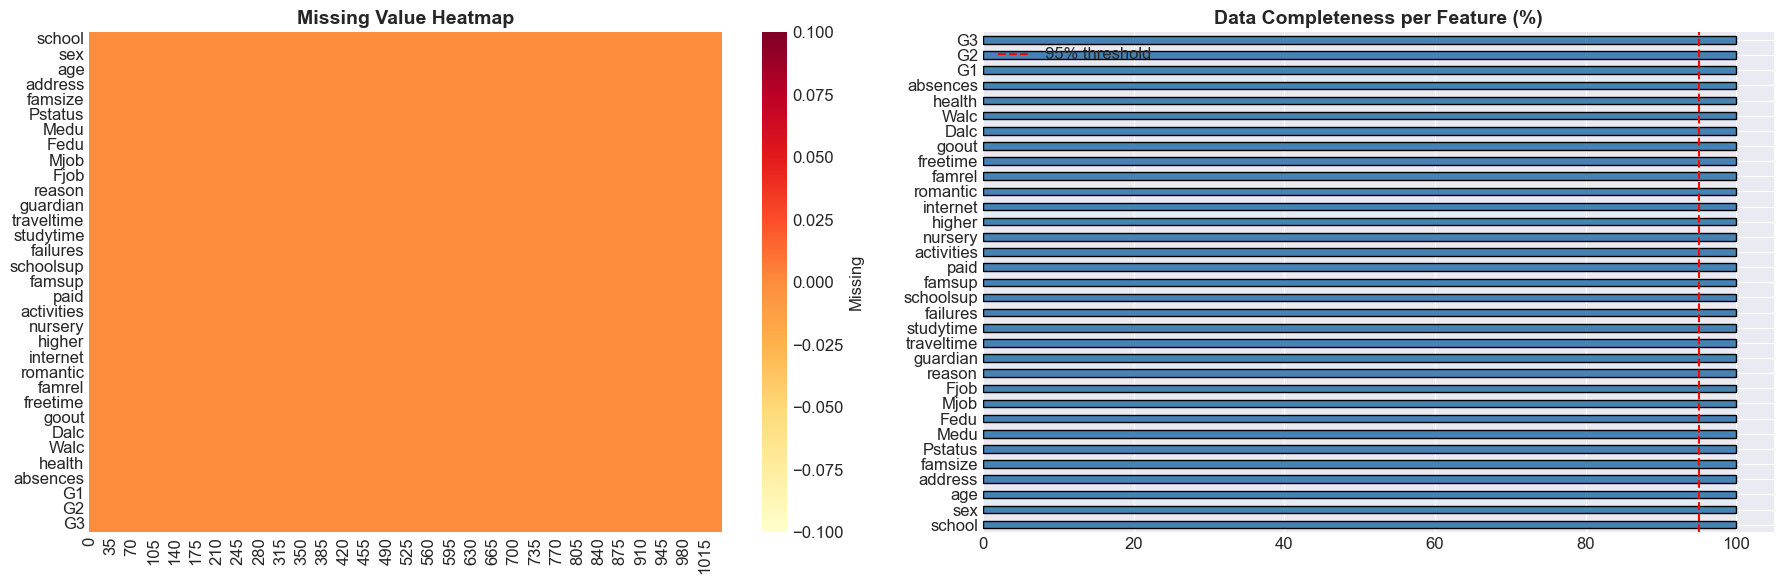

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

sns.heatmap(df.isnull().T, cbar=True, yticklabels=True,
            ax=axes[0], cmap='YlOrRd', cbar_kws={'label': 'Missing'})
axes[0].set_title('Missing Value Heatmap', fontweight='bold')

completeness = (1 - df.isnull().mean()) * 100
completeness.sort_values().plot(kind='barh', ax=axes[1], color='steelblue', edgecolor='black')
axes[1].set_title('Data Completeness per Feature (%)', fontweight='bold')
axes[1].axvline(x=95, color='red', linestyle='--', label='95% threshold')
axes[1].legend()

plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, 'step2_missing_analysis.png'), dpi=150, bbox_inches='tight')
plt.show()


## Step 3: Distribution EDA
> Check grade distributions for normality/skewness. Identify heavily skewed features.


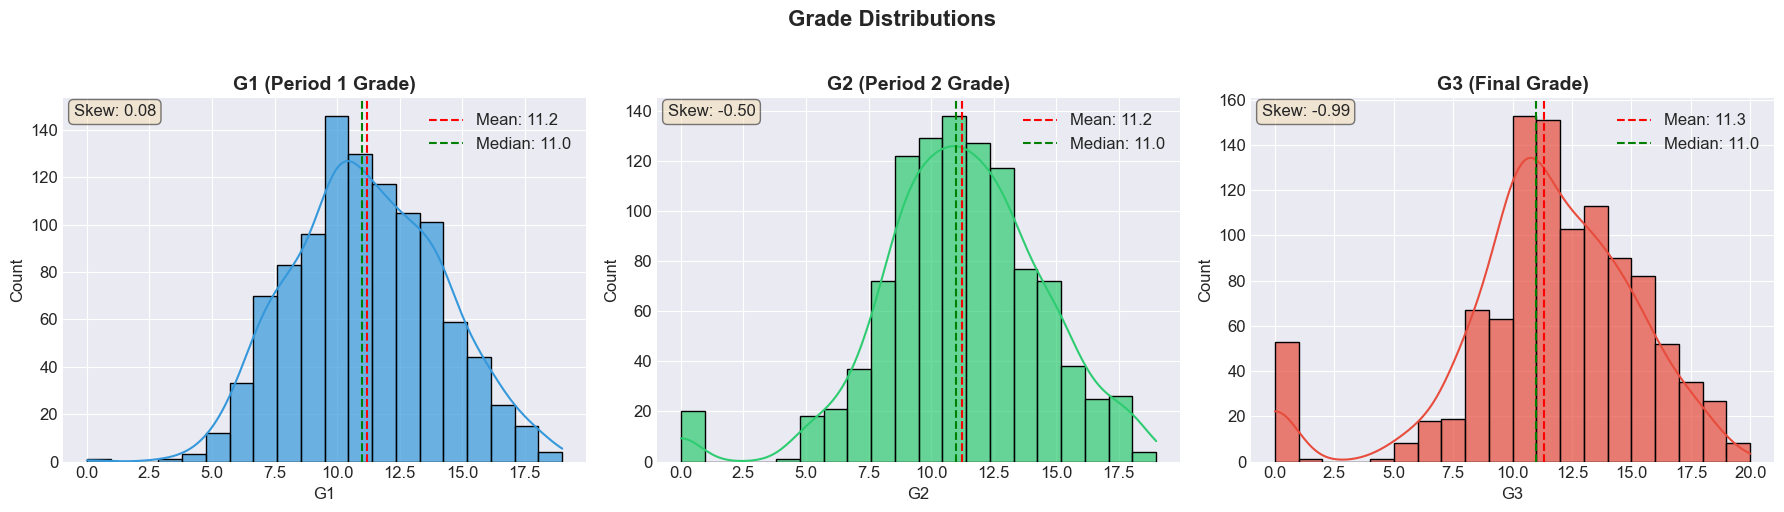

In [7]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
grade_colors = ['#3498db', '#2ecc71', '#e74c3c']
grade_names = ['Period 1', 'Period 2', 'Final']

for i, col in enumerate(['G1', 'G2', 'G3']):
    sns.histplot(df[col], kde=True, ax=axes[i], bins=20,
                 color=grade_colors[i], edgecolor='black', alpha=0.7)
    axes[i].set_title(f'{col} ({grade_names[i]} Grade)', fontweight='bold')
    axes[i].axvline(df[col].mean(), color='red', linestyle='--',
                    label=f'Mean: {df[col].mean():.1f}')
    axes[i].axvline(df[col].median(), color='green', linestyle='--',
                    label=f'Median: {df[col].median():.1f}')
    axes[i].legend()
    skew = df[col].skew()
    axes[i].text(0.02, 0.95, f'Skew: {skew:.2f}', transform=axes[i].transAxes,
                 bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.suptitle('Grade Distributions', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, 'step3_grade_distributions.png'), dpi=150, bbox_inches='tight')
plt.show()


In [8]:
# Skewness table
skewness = df[numeric_cols].skew().sort_values()
def skew_status(s):
    if abs(s) < 0.5: return 'Normal'
    if abs(s) < 1.0: return 'Moderate'
    return 'Highly Skewed'

skew_df = pd.DataFrame({'Skewness': skewness, 'Status': skewness.apply(skew_status)})
skew_df


,Skewness,Status
famrel,-1.055775,Highly Skewed
G3,-0.985965,Moderate
health,-0.498800,Normal
G2,-0.497357,Normal
freetime,-0.178707,Normal
Medu,-0.139528,Normal
goout,0.038928,Normal
G1,0.077922,Normal
Fedu,0.119447,Normal
age,0.434028,Normal


## Step 4: Time-Series EDA
> Track grade progression G1 -> G2 -> G3 for each student.  
> Detect dropouts (G3=0) and measure improvement vs decline trends.


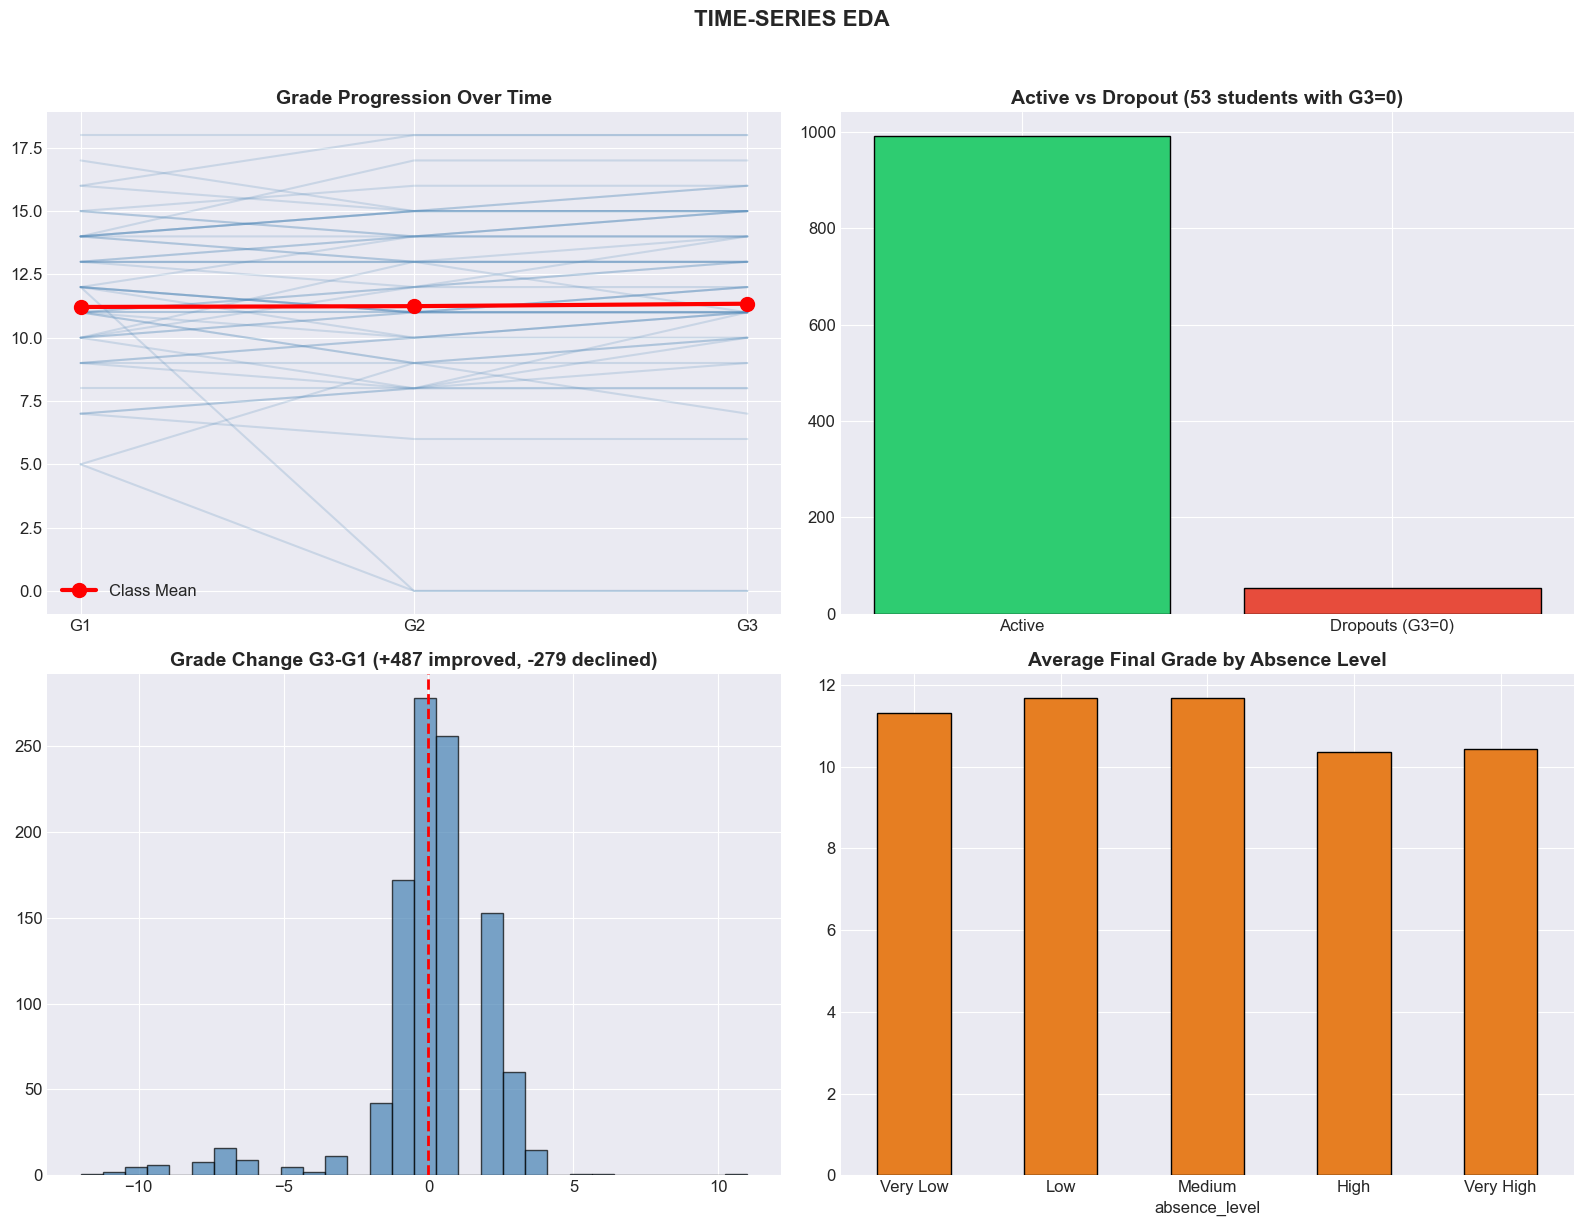

Dropouts (G3=0): 53 (5.1%)
Improved: 487 | Declined: 279 | Stable: 278


In [9]:
df['grade_change'] = df['G3'] - df['G1']
improved = (df['grade_change'] > 0).sum()
declined = (df['grade_change'] < 0).sum()
same     = (df['grade_change'] == 0).sum()
n_dropout = (df['G3'] == 0).sum()

# Absence level bins
bins_abs   = [0, 2, 5, 10, 20, df['absences'].max() + 1]
labels_abs = ['Very Low', 'Low', 'Medium', 'High', 'Very High']
df['absence_level'] = pd.cut(df['absences'], bins=bins_abs, labels=labels_abs, include_lowest=True)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Grade progression lines
grade_progression = df[['G1', 'G2', 'G3']].T
sample_students = np.random.choice(len(df), min(50, len(df)), replace=False)
for idx in sample_students:
    axes[0,0].plot(['G1', 'G2', 'G3'], grade_progression[idx].values, alpha=0.2, color='steelblue')
axes[0,0].plot(['G1', 'G2', 'G3'],
               [df['G1'].mean(), df['G2'].mean(), df['G3'].mean()],
               'ro-', linewidth=3, markersize=10, label='Class Mean')
axes[0,0].set_title('Grade Progression Over Time', fontweight='bold')
axes[0,0].legend()

# Dropout bar
axes[0,1].bar(['Active', 'Dropouts (G3=0)'], [len(df) - n_dropout, n_dropout],
              color=['#2ecc71', '#e74c3c'], edgecolor='black')
axes[0,1].set_title(f'Active vs Dropout ({n_dropout} students with G3=0)', fontweight='bold')

# Grade change histogram
axes[1,0].hist(df['grade_change'], bins=30, color='steelblue', edgecolor='black', alpha=0.7)
axes[1,0].axvline(0, color='red', linestyle='--', linewidth=2)
axes[1,0].set_title(f'Grade Change G3-G1 (+{improved} improved, -{declined} declined)', fontweight='bold')

# Absences vs grade
df.groupby('absence_level', observed=True)['G3'].mean().plot(
    kind='bar', ax=axes[1,1], color='#e67e22', edgecolor='black')
axes[1,1].set_title('Average Final Grade by Absence Level', fontweight='bold')
axes[1,1].tick_params(axis='x', rotation=0)

plt.suptitle('TIME-SERIES EDA', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, 'step4_timeseries_eda.png'), dpi=150, bbox_inches='tight')
plt.show()

print(f'Dropouts (G3=0): {n_dropout} ({n_dropout/len(df)*100:.1f}%)')
print(f'Improved: {improved} | Declined: {declined} | Stable: {same}')


## Step 5: Categorical EDA
> Compare G3 distributions across categorical groups: gender, school, age, parent education, study time.


In [10]:
cat_cols = df.select_dtypes(include=['object']).columns.tolist()
print(f'Categorical columns ({len(cat_cols)}): {cat_cols}')


Categorical columns (17): ['school', 'sex', 'address', 'famsize', 'Pstatus', 'Mjob', 'Fjob', 'reason', 'guardian', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic']


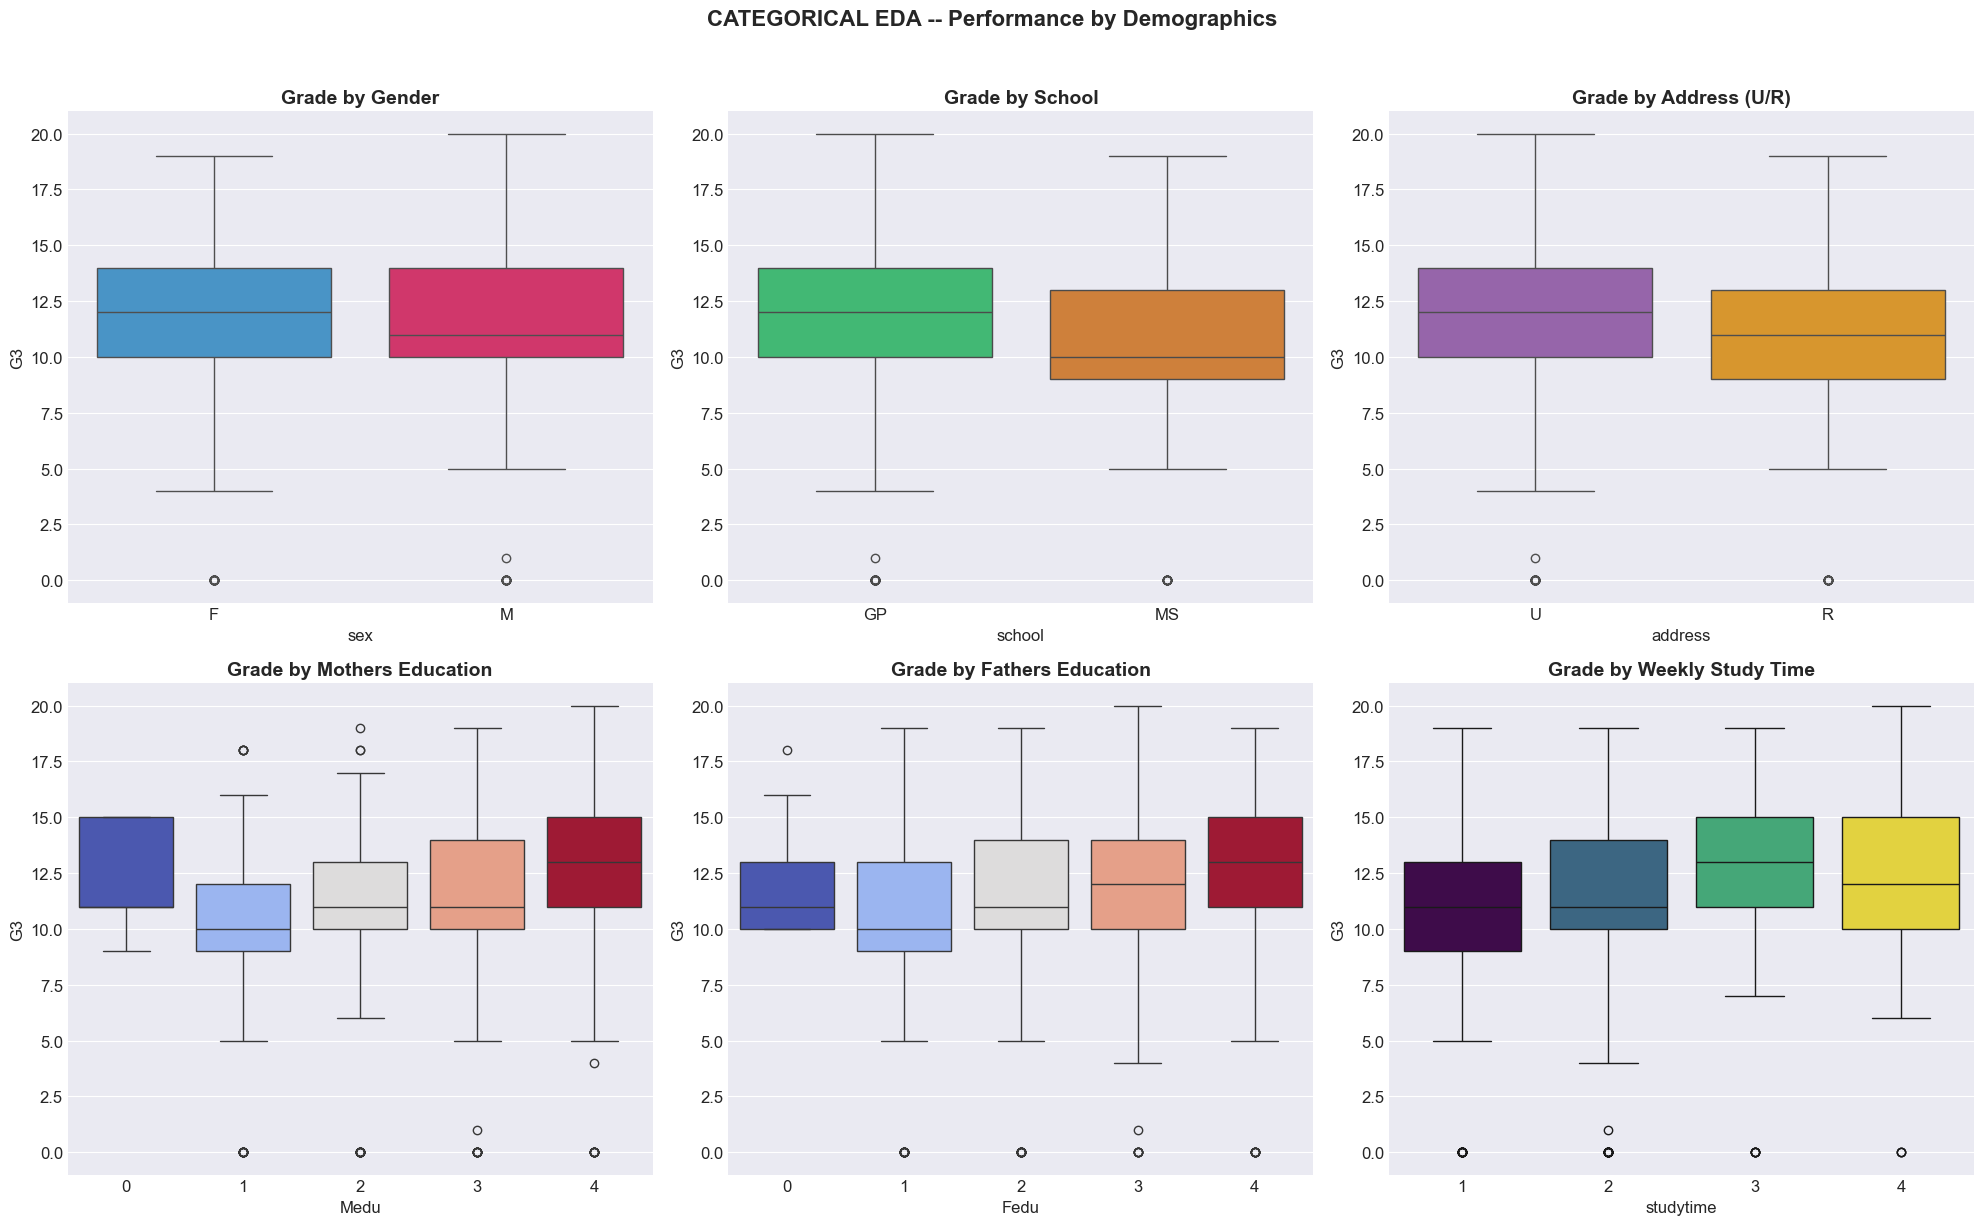

In [11]:
fig, axes = plt.subplots(2, 3, figsize=(20, 12))

plots = [
    ('sex',       'Grade by Gender',           ['#3498db','#e91e63']),
    ('school',    'Grade by School',            ['#2ecc71','#e67e22']),
    ('address',   'Grade by Address (U/R)',      ['#9b59b6','#f39c12']),
    ('Medu',      'Grade by Mothers Education', 'coolwarm'),
    ('Fedu',      'Grade by Fathers Education', 'coolwarm'),
    ('studytime', 'Grade by Weekly Study Time', 'viridis'),
]

for ax, (col, title, pal) in zip(axes.flatten(), plots):
    sns.boxplot(data=df, x=col, y='G3', ax=ax, hue=col, legend=False, palette=pal)
    ax.set_title(title, fontweight='bold')

plt.suptitle('CATEGORICAL EDA -- Performance by Demographics', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, 'step5_categorical_eda.png'), dpi=150, bbox_inches='tight')
plt.show()


In [12]:
# Summary stats per category
for cat in ['sex', 'school', 'address']:
    print(f'\n-- G3 by {cat} --')
    print(df.groupby(cat)['G3'].agg(['mean','median','std','count']).round(2))



-- G3 by sex --
      mean  median   std  count
sex                            
F    11.45    12.0  3.87    591
M    11.20    11.0  3.85    453

-- G3 by school --
         mean  median   std  count
school                            
GP      11.63    12.0  3.81    772
MS      10.51    10.0  3.91    272

-- G3 by address --
          mean  median   std  count
address                            
R        10.60    11.0  3.98    285
U        11.62    12.0  3.78    759


## Step 6: Correlation Analysis
> Identify features most correlated with G3 (final grade).  
> **Key Finding**: G2 (r=0.911) and G1 (r=0.809) are far the strongest predictors.


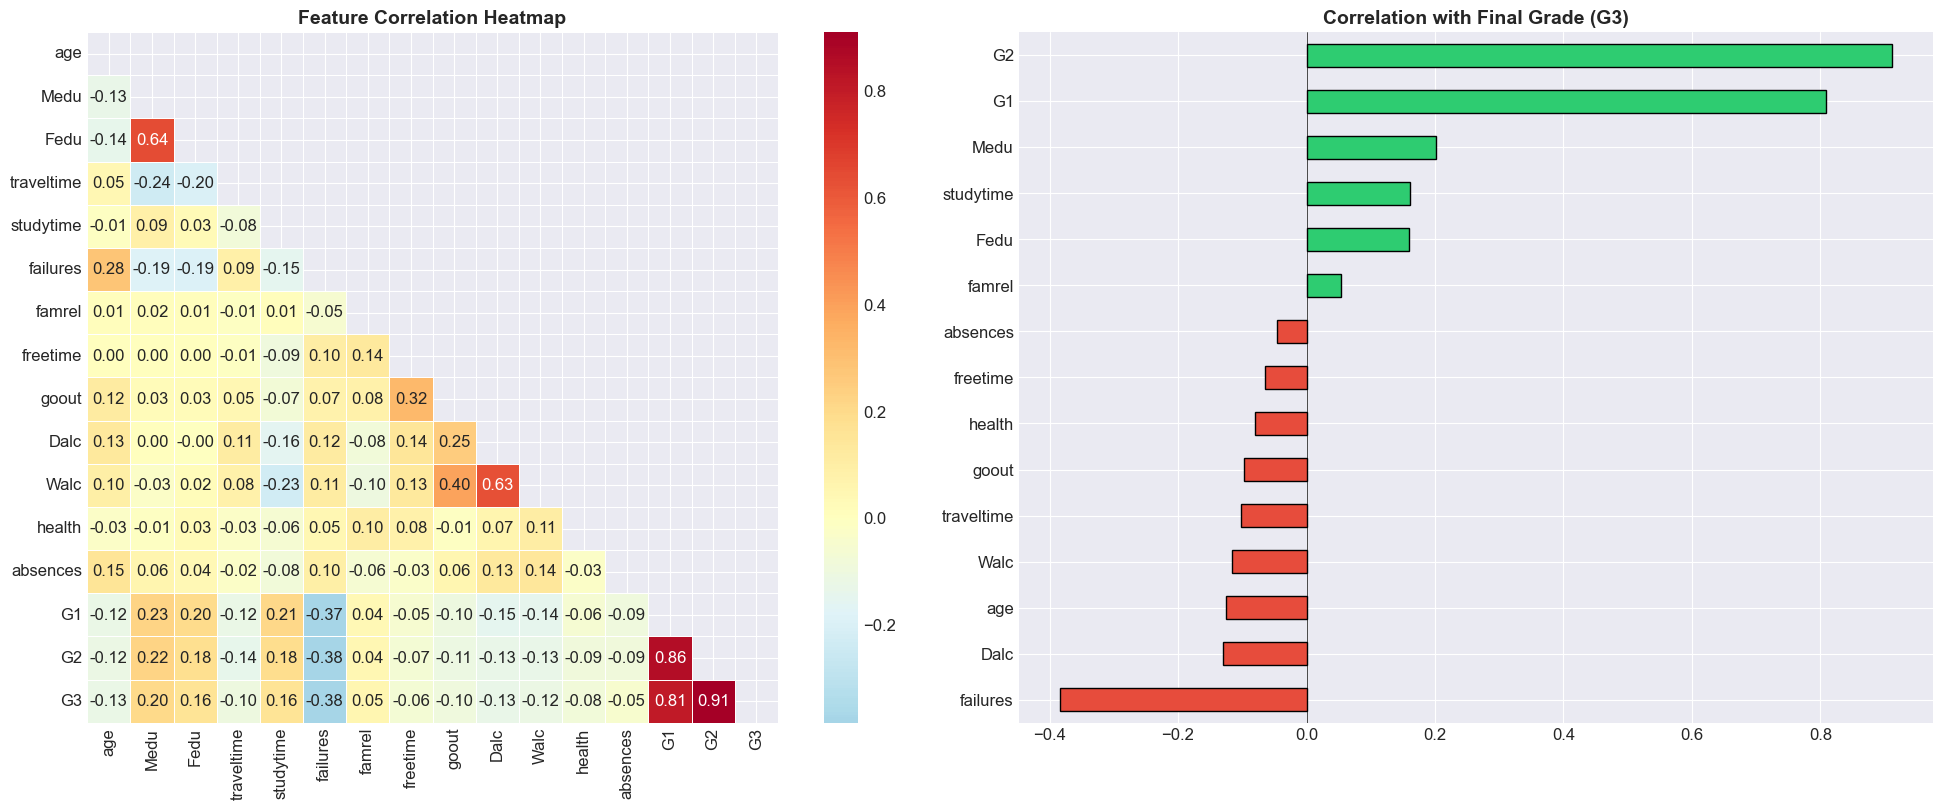

In [13]:
corr_matrix = df[numeric_cols].corr()

fig, axes = plt.subplots(1, 2, figsize=(20, 8))

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='RdYlBu_r', center=0, ax=axes[0], square=True, linewidths=0.5)
axes[0].set_title('Feature Correlation Heatmap', fontweight='bold')

g3_corr = corr_matrix['G3'].drop('G3').sort_values(ascending=True)
colors = ['#e74c3c' if v < 0 else '#2ecc71' for v in g3_corr]
g3_corr.plot(kind='barh', ax=axes[1], color=colors, edgecolor='black')
axes[1].set_title('Correlation with Final Grade (G3)', fontweight='bold')
axes[1].axvline(0, color='black', linewidth=0.5)

plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, 'step6_correlation.png'), dpi=150, bbox_inches='tight')
plt.show()


In [14]:
# Top correlations with G3
top_corr = pd.DataFrame({
    'Feature': g3_corr.abs().sort_values(ascending=False).head(10).index,
    'Correlation': g3_corr.abs().sort_values(ascending=False).head(10).values,
    'Direction': ['+' if corr_matrix.loc['G3', f] > 0 else '-'
                  for f in g3_corr.abs().sort_values(ascending=False).head(10).index]
})
top_corr


,Feature,Correlation,Direction
0,G2,0.910743,+
1,G1,0.809142,+
2,failures,0.383145,-
3,Medu,0.201472,+
4,studytime,0.161629,+
5,Fedu,0.159796,+
6,Dalc,0.129642,-
7,age,0.125282,-
8,Walc,0.115740,-
9,traveltime,0.102627,-


## Step 7: Class Imbalance Analysis
> At-risk students: G3 < 10. Passing students: G3 >= 10.  
> **Result**: 1:3.5 imbalance — 814 pass vs 230 at-risk.


In [15]:
df['at_risk']    = (df['G3'] < 10).astype(int)
df['risk_label'] = df['at_risk'].map({0: 'Pass (G3>=10)', 1: 'At-Risk (G3<10)'})
risk_counts = df['risk_label'].value_counts()
risk_ratio  = risk_counts.min() / risk_counts.max()

print(f'Pass:    {risk_counts.get("Pass (G3>=10)", 0)}')
print(f'At-Risk: {risk_counts.get("At-Risk (G3<10)", 0)}')
print(f'Ratio:   1:{1/risk_ratio:.1f}')


Pass:    814
At-Risk: 230
Ratio:   1:3.5


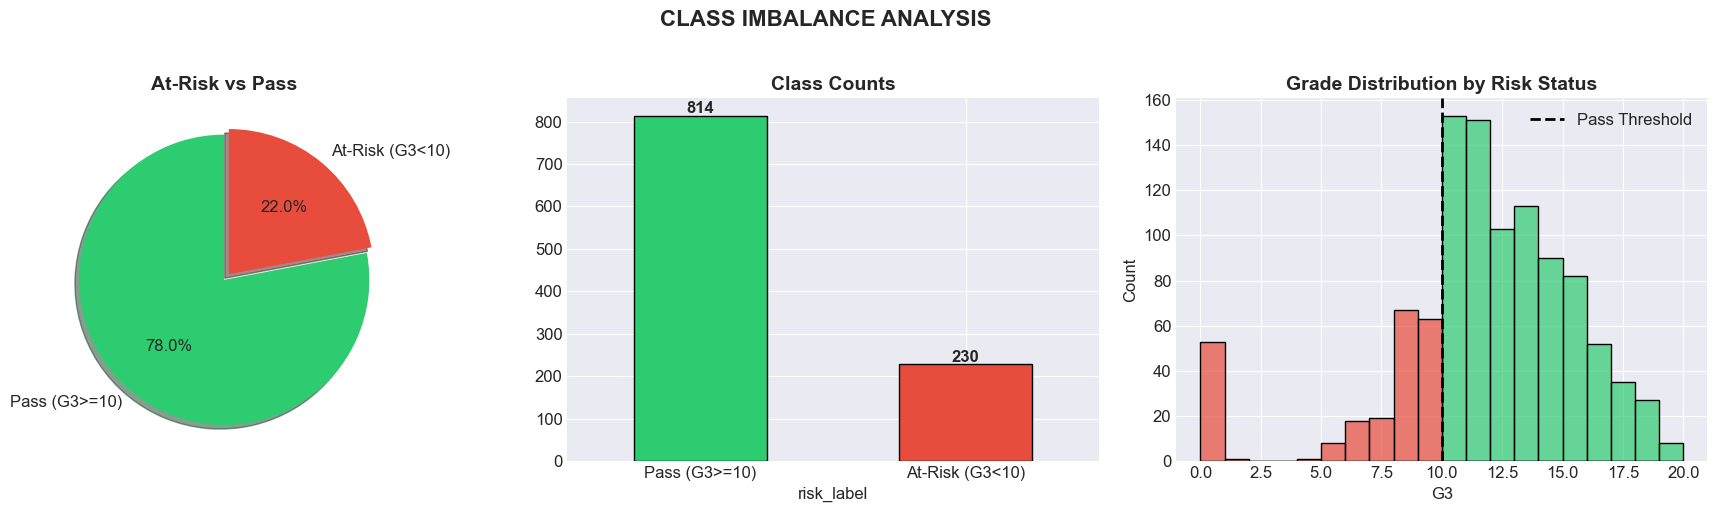

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

risk_counts.plot(kind='pie', ax=axes[0], autopct='%1.1f%%',
                 colors=['#2ecc71','#e74c3c'], startangle=90,
                 explode=[0, 0.05], shadow=True)
axes[0].set_title('At-Risk vs Pass', fontweight='bold')
axes[0].set_ylabel('')

risk_counts.plot(kind='bar', ax=axes[1], color=['#2ecc71','#e74c3c'], edgecolor='black')
axes[1].set_title('Class Counts', fontweight='bold')
axes[1].tick_params(axis='x', rotation=0)
for i, v in enumerate(risk_counts.values):
    axes[1].text(i, v+5, str(v), ha='center', fontweight='bold')

sns.histplot(data=df, x='G3', hue='risk_label', bins=20, ax=axes[2],
             palette={'Pass (G3>=10)': '#2ecc71', 'At-Risk (G3<10)': '#e74c3c'},
             edgecolor='black', alpha=0.7)
axes[2].axvline(10, color='black', linestyle='--', linewidth=2, label='Pass Threshold')
axes[2].set_title('Grade Distribution by Risk Status', fontweight='bold')
axes[2].legend()

plt.suptitle('CLASS IMBALANCE ANALYSIS', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, 'step7_class_imbalance.png'), dpi=150, bbox_inches='tight')
plt.show()


## Step 8: Target Engineering
> Define mastery levels (0-4 scale) from G3 for DKT LSTM training.

| Level | Label | Grade Range | Description |
|-------|-------|-------------|-------------|
| 0 | No Mastery | 0-4 | Failing badly |
| 1 | Beginner | 5-8 | Below pass mark |
| 2 | Developing | 9-12 | Around passing |
| 3 | Proficient | 13-16 | Good performance |
| 4 | Master | 17-20 | Excellent |


In [17]:
def assign_mastery(grade):
    if grade <= 4:  return 0  # No Mastery
    elif grade <= 8:  return 1  # Beginner
    elif grade <= 12: return 2  # Developing
    elif grade <= 16: return 3  # Proficient
    else: return 4  # Master

mastery_labels = {
    0: 'No Mastery (0-4)',   1: 'Beginner (5-8)',
    2: 'Developing (9-12)',  3: 'Proficient (13-16)',
    4: 'Master (17-20)'
}

df['mastery_level'] = df['G3'].apply(assign_mastery)
df['mastery_label'] = df['mastery_level'].map(mastery_labels)

mastery_dist = df['mastery_level'].value_counts().sort_index()
pd.DataFrame({'Count': mastery_dist,
              'Label': [mastery_labels[i] for i in mastery_dist.index],
              'Percent': (mastery_dist / len(df) * 100).round(1)})


,Count,Label,Percent
mastery_level,,,
0,55,No Mastery (0-4),5.3
1,112,Beginner (5-8),10.7
2,470,Developing (9-12),45.0
3,337,Proficient (13-16),32.3
4,70,Master (17-20),6.7


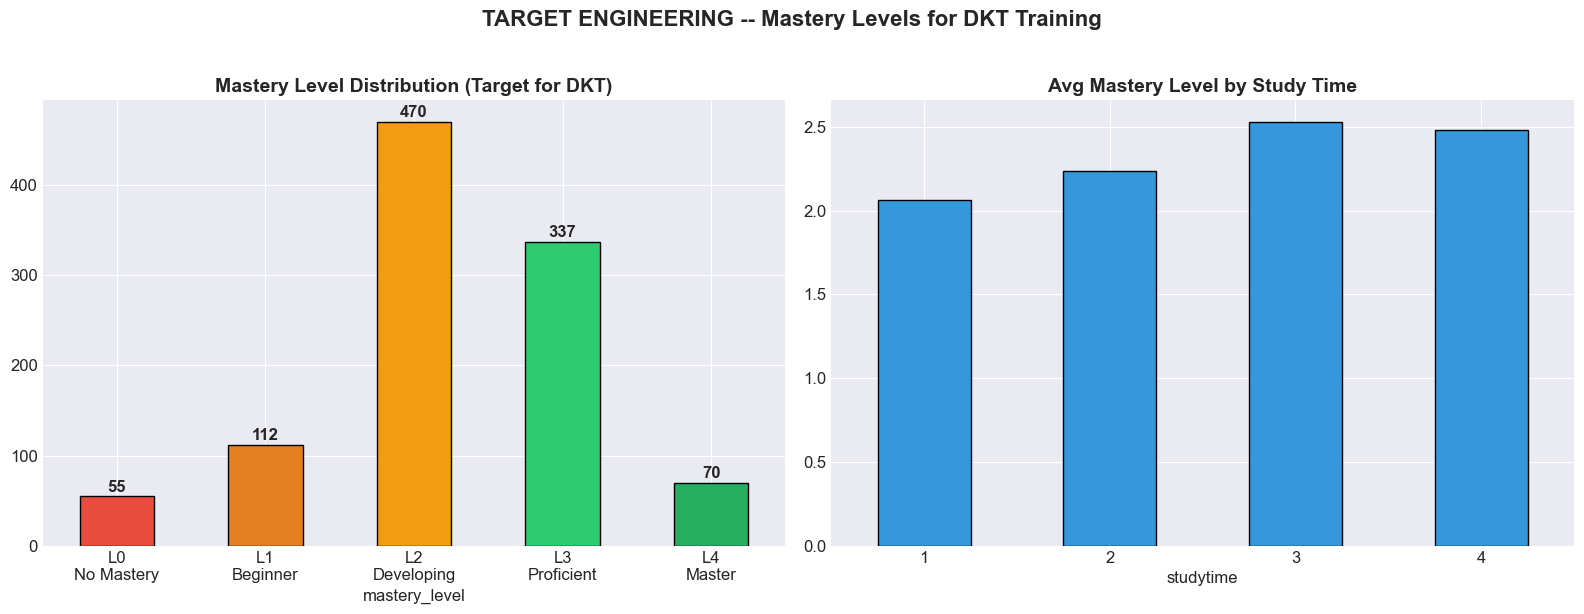

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

colors_mastery = ['#e74c3c','#e67e22','#f39c12','#2ecc71','#27ae60']
mastery_dist.plot(kind='bar', ax=axes[0], color=colors_mastery, edgecolor='black')
axes[0].set_title('Mastery Level Distribution (Target for DKT)', fontweight='bold')
axes[0].set_xticklabels(['L0\nNo Mastery','L1\nBeginner','L2\nDeveloping',
                          'L3\nProficient','L4\nMaster'], rotation=0)
for i, v in enumerate(mastery_dist.values):
    axes[0].text(i, v+5, str(v), ha='center', fontweight='bold')

df.groupby('studytime')['mastery_level'].mean().plot(
    kind='bar', ax=axes[1], color='#3498db', edgecolor='black')
axes[1].set_title('Avg Mastery Level by Study Time', fontweight='bold')
axes[1].tick_params(axis='x', rotation=0)

plt.suptitle('TARGET ENGINEERING -- Mastery Levels for DKT Training',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, 'step8_target_engineering.png'), dpi=150, bbox_inches='tight')
plt.show()


## Save Processed Data


In [ ]:
processed_path = os.path.join('..', 'data', 'processed', 'student_performance_processed.csv')
df.to_csv(processed_path, index=False)
print(f'[SAVE] {os.path.abspath(processed_path)}')
print(f'[INFO] Final shape: {df.shape}')
print(f'[INFO] New columns: grade_change, absence_level, at_risk, risk_label, mastery_level, mastery_label')


[SAVE] d:\Day 1\project\data\processed\student_performance_processed.csv
[INFO] Final shape: (1044, 39)
[INFO] New columns: grade_change, absence_level, at_risk, risk_label, mastery_level, mastery_label


: 

## EDA Summary
| Finding | Value |
|---------|-------|
| Total Students | 1,044 |
| Missing Values | None (100% complete) |
| Strongest G3 Predictor | G2 (r = 0.911) |
| Potential Dropouts (G3=0) | 53 (5.1%) |
| Students Improved G1->G3 | 487 (46.6%) |
| Class Imbalance | 1:3.5 (pass:at-risk) |
| Most Common Mastery Level | Level 2 - Developing (45%) |

> **Next step**: Run `run_pipeline.ipynb` to train models and run the AI agent.
